# ViCTSD — Vietnamese Text Classification

**Course:** CO5177 — Programming Foundation for Data Analytics and Visualization

**Student:** Dinh Hoang Duy Khanh — 2670306

**Group:** Trailblazer

This notebook studies Vietnamese social-media comments from ViCTSD. The main
task is toxicity classification. Constructiveness is reported as a second task.

## 0. Import libraries

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import balanced_accuracy_score, classification_report, f1_score
from sklearn.naive_bayes import MultinomialNB

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180})
colors = ["#d35b12", "#efae00", "#173f4c"]

In [4]:
project_folder = Path.cwd()
if project_folder.name == "notebooks":
    project_folder = project_folder.parent

figure_folder = project_folder / "reports" / "figures"
figure_folder.mkdir(parents=True, exist_ok=True)

In [5]:
def save_plot(name):
    plt.tight_layout()
    plt.savefig(figure_folder / name, bbox_inches="tight", facecolor="white")
    plt.show()

## 1. Load the official splits

In [6]:
def load_split(name):
    local_file = project_folder / "data" / f"victsd_{name}.csv"
    source_url = f"https://raw.githubusercontent.com/tarudesu/ViCTSD/main/ViCTSD_{name}.csv"
    return pd.read_csv(local_file if local_file.exists() else source_url)

In [7]:
train = load_split("train")
valid = load_split("valid")
test = load_split("test")

In [8]:
for frame in [train, valid, test]:
    frame.drop(columns="Unnamed: 0", inplace=True)

train.head()

,Comment,Constructiveness,Toxicity,Title,Topic
0,Thật tuyệt vời...!!!,0,0,Những 'bước tiến diệu kỳ' của Trúc Nhi - Diệu Nhi,SucKhoe
1,"mỹ đã tuột dốc quá nhiều rồi, giờ muốn vực dậy...",1,0,Hình tượng Mỹ sụp đổ trong lòng người dân thế ...,TheGioi
2,tôi thấy người lái xe hơi bấm còi mới là người...,1,1,Cả trăm người đạp xe thể dục bịt kín đường,OtoXemay
3,Coi dịch là giặc. Đã mang tên đó mà xâm nhập V...,0,0,11 ngày không lây nhiễm nCoV cộng đồng,SucKhoe
4,Thương các bé quá! Các con còn quá nhỏ mà đã p...,0,0,5 trẻ chết đuối dưới ao,ThoiSu


In [9]:
print("Train:", train.shape)
print("Validation:", valid.shape)
print("Test:", test.shape)
print("All comments:", len(train) + len(valid) + len(test))

Train: (7000, 5)
Validation: (2000, 5)
Test: (1000, 5)
All comments: 10000


In [10]:
print("Missing values:")
print(train.isnull().sum())
print("Duplicate rows in train:", train.duplicated().sum())

Missing values:
Comment             0
Constructiveness    0
Toxicity            0
Title               0
Topic               0
dtype: int64
Duplicate rows in train: 1


ViCTSD has 10,000 human-annotated Vietnamese comments. The official split is
7,000 train, 2,000 validation, and 1,000 test comments.

## 2. Dataset overview

In [11]:
split_sizes = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Comments": [len(train), len(valid), len(test)],
})
split_sizes

,Split,Comments
0,Train,7000
1,Validation,2000
2,Test,1000


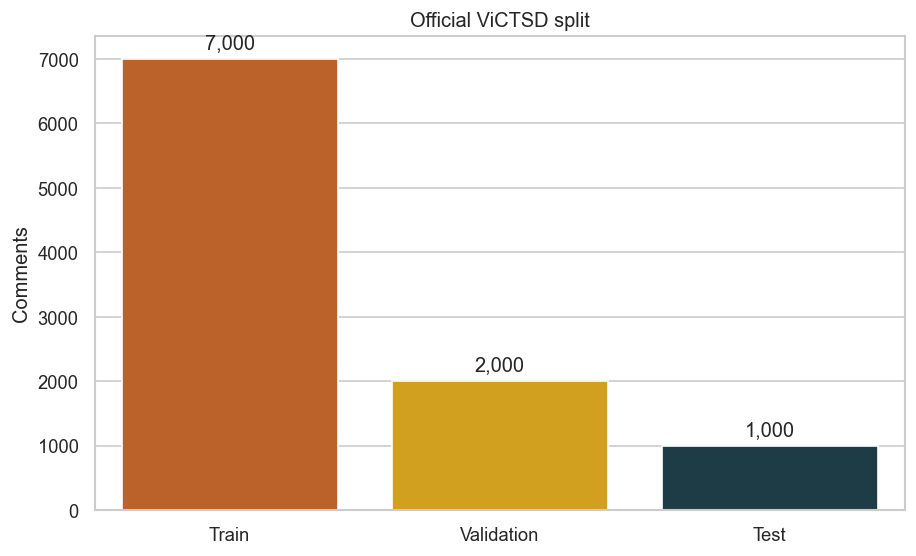

In [12]:
plt.figure(figsize=(7.8, 4.8))
ax = sns.barplot(data=split_sizes, x="Split", y="Comments", hue="Split", palette=colors, legend=False)
for bar in ax.containers:
    ax.bar_label(bar, fmt="{:,.0f}", padding=4)
ax.set(title="Official ViCTSD split", xlabel="", ylabel="Comments")
save_plot("text_01_split_sizes.png")

In [13]:
train["Split"] = "Train"
valid["Split"] = "Validation"
test["Split"] = "Test"
all_data = pd.concat([train, valid, test], ignore_index=True)

In [14]:
print("Topics:", all_data["Topic"].nunique())
print("Exact duplicate comments:", all_data["Comment"].duplicated().sum())
pd.crosstab(all_data["Constructiveness"], all_data["Toxicity"])

Topics: 10
Exact duplicate comments: 65


Toxicity,0,1
Constructiveness,,
0,5588,816
1,3311,285


## 3. Label and topic distributions

In [15]:
label_data = all_data.melt(
    value_vars=["Constructiveness", "Toxicity"],
    var_name="Task", value_name="Label",
)
label_data["Class"] = label_data["Label"].map({0: "Class 0", 1: "Class 1"})

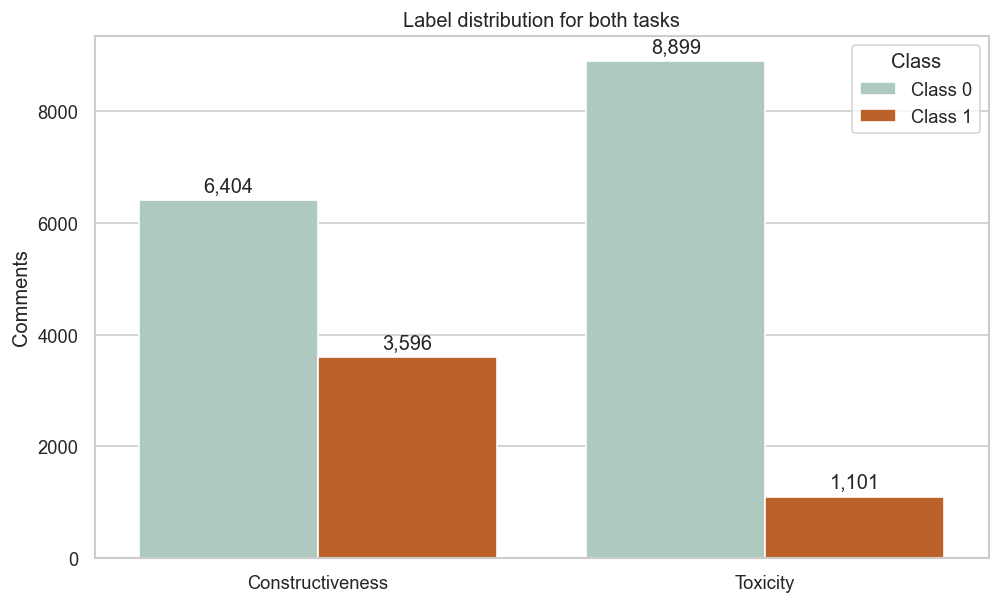

In [16]:
plt.figure(figsize=(8.5, 5.2))
ax = sns.countplot(data=label_data, x="Task", hue="Class", palette=["#a9cfc1", "#d35b12"])
for bar in ax.containers:
    ax.bar_label(bar, fmt="{:,.0f}", padding=3)
ax.set(title="Label distribution for both tasks", xlabel="", ylabel="Comments")
save_plot("text_02_label_distribution.png")

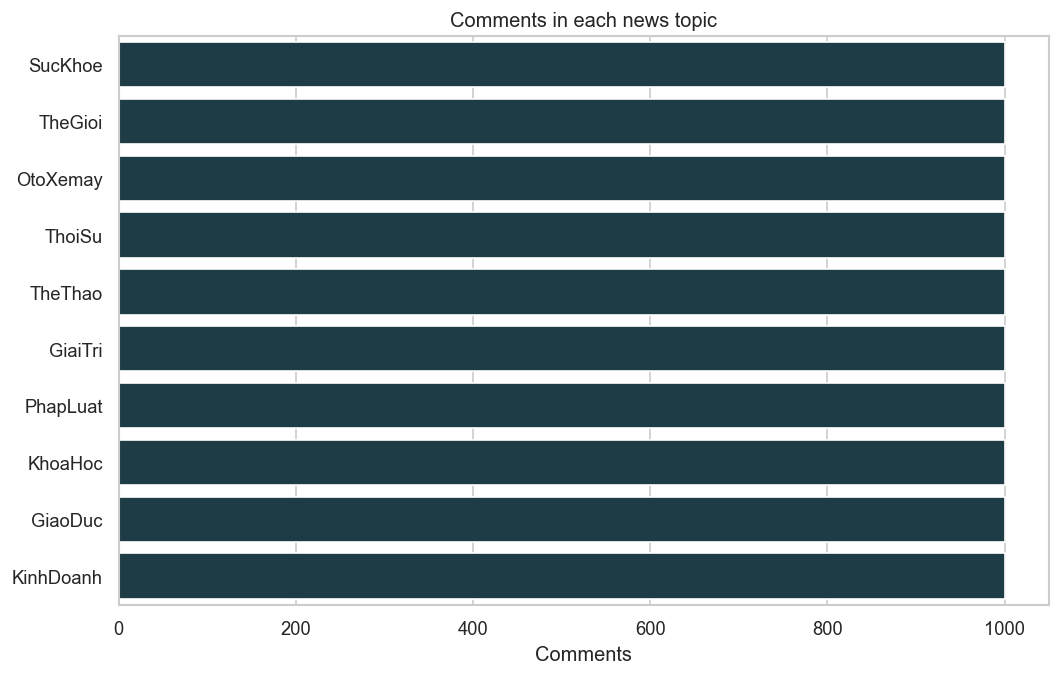

In [17]:
topic_counts = all_data["Topic"].value_counts().sort_values()
plt.figure(figsize=(9, 5.8))
sns.barplot(x=topic_counts.values, y=topic_counts.index, color="#173f4c")
plt.title("Comments in each news topic")
plt.xlabel("Comments")
plt.ylabel("")
save_plot("text_03_topic_distribution.png")

The dataset is balanced by topic (1,000 comments each) but toxicity is rare.
This makes accuracy alone a misleading metric for the toxicity task.

## 4. Clean text and audit duplicates

In [18]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

In [19]:
for frame in [train, valid, test]:
    frame["CleanComment"] = frame["Comment"].map(clean_text)
    frame["Characters"] = frame["Comment"].str.len()
    frame["Words"] = frame["CleanComment"].str.split().str.len()

all_data = pd.concat([train, valid, test], ignore_index=True)

In [20]:
known_comments = set(train["CleanComment"])
valid_eval = valid[~valid["CleanComment"].isin(known_comments)].reset_index(drop=True)
test_eval = test[~test["CleanComment"].isin(known_comments)].reset_index(drop=True)

In [21]:
print("Validation comments removed for overlap:", len(valid) - len(valid_eval))
print("Test comments removed for overlap:", len(test) - len(test_eval))
print("Validation used for evaluation:", len(valid_eval))
print("Test used for evaluation:", len(test_eval))

Validation comments removed for overlap: 32
Test comments removed for overlap: 15
Validation used for evaluation: 1968
Test used for evaluation: 985


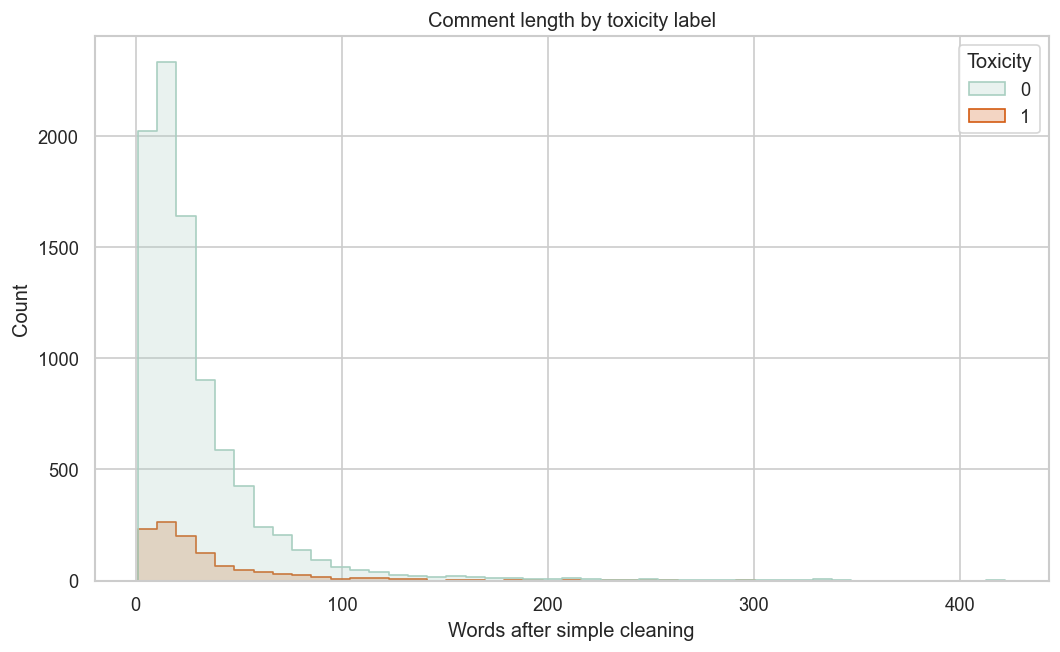

In [22]:
plt.figure(figsize=(9, 5.6))
sns.histplot(data=all_data, x="Words", hue="Toxicity", bins=45,
             palette=["#a9cfc1", "#d35b12"], element="step")
plt.title("Comment length by toxicity label")
plt.xlabel("Words after simple cleaning")
save_plot("text_04_comment_length.png")

Only simple cleaning is used: lowercase, remove URLs and punctuation, then
collapse spaces. Titles and topics are not used as model inputs.

## 5. TF-IDF features

In [23]:
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True,
)

In [24]:
X_train_word = word_vectorizer.fit_transform(train["CleanComment"])
X_valid_word = word_vectorizer.transform(valid_eval["CleanComment"])
X_test_word = word_vectorizer.transform(test_eval["CleanComment"])
print("Word TF-IDF features:", X_train_word.shape[1])

Word TF-IDF features: 8000


In [25]:
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=12000, sublinear_tf=True,
)

In [26]:
X_train_char = char_vectorizer.fit_transform(train["CleanComment"])
X_valid_char = char_vectorizer.transform(valid_eval["CleanComment"])
print("Character TF-IDF features:", X_train_char.shape[1])

Character TF-IDF features: 12000


## 6. Words and phrases related to toxicity

In [27]:
toxic_word_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
toxic_word_model.fit(X_train_word, train["Toxicity"])
toxic_valid_pred = toxic_word_model.predict(X_valid_word)

In [28]:
terms = word_vectorizer.get_feature_names_out()
weights = pd.DataFrame({"Term": terms, "Weight": toxic_word_model.coef_[0]})
toxic_terms = weights.nlargest(15, "Weight").sort_values("Weight")
safe_terms = weights.nsmallest(15, "Weight").sort_values("Weight", ascending=False)

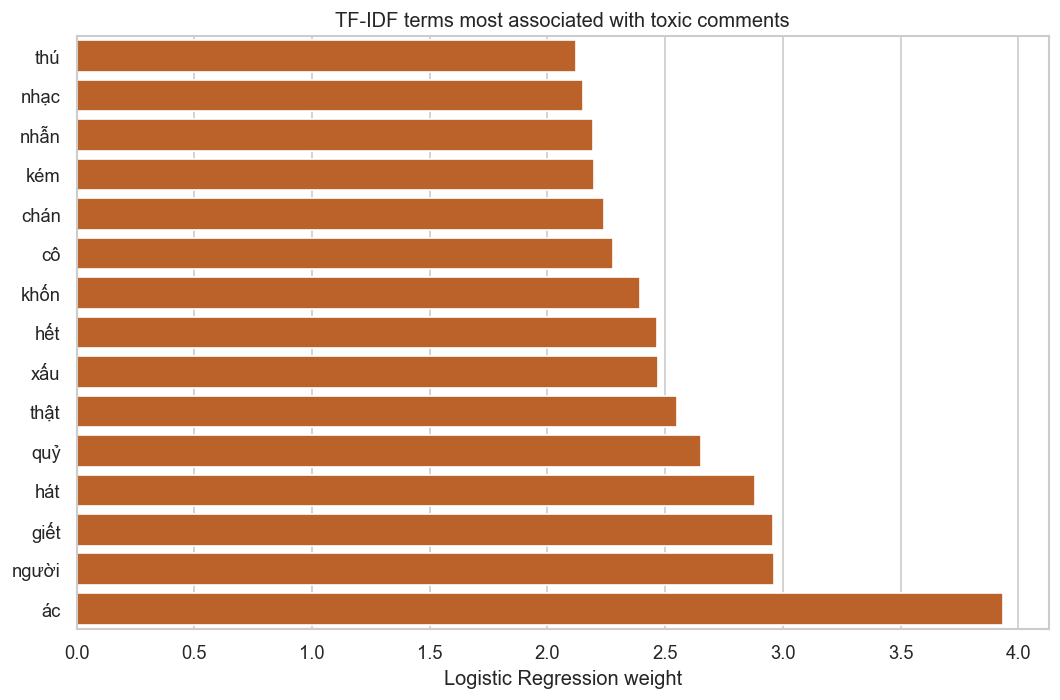

In [29]:
plt.figure(figsize=(9, 6))
sns.barplot(data=toxic_terms, x="Weight", y="Term", color="#d35b12")
plt.title("TF-IDF terms most associated with toxic comments")
plt.xlabel("Logistic Regression weight")
plt.ylabel("")
save_plot("text_05_top_toxic_ngrams.png")

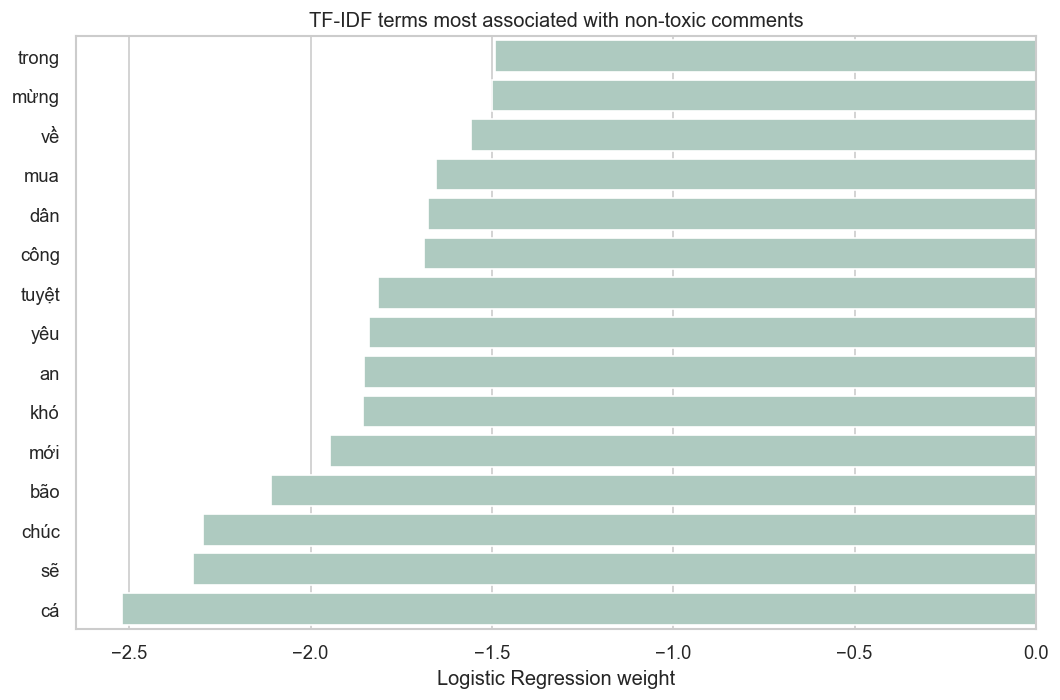

In [30]:
plt.figure(figsize=(9, 6))
sns.barplot(data=safe_terms, x="Weight", y="Term", color="#a9cfc1")
plt.title("TF-IDF terms most associated with non-toxic comments")
plt.xlabel("Logistic Regression weight")
plt.ylabel("")
save_plot("text_06_top_safe_ngrams.png")

These weights explain which n-grams push a comment toward toxic or non-toxic.
They are model signals, not a list of words that always determine toxicity.

## 7. Toxicity model comparison

In [31]:
toxic_nb = MultinomialNB()
toxic_nb.fit(X_train_word, train["Toxicity"])
toxic_nb_pred = toxic_nb.predict(X_valid_word)

In [32]:
toxic_char_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
toxic_char_model.fit(X_train_char, train["Toxicity"])
toxic_char_pred = toxic_char_model.predict(X_valid_char)

In [33]:
def score_model(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        balanced_accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, pos_label=1),
        f1_score(y_true, y_pred, average="macro"),
    ]

In [34]:
toxic_scores = pd.DataFrame(
    [score_model(valid_eval["Toxicity"], toxic_nb_pred),
     score_model(valid_eval["Toxicity"], toxic_valid_pred),
     score_model(valid_eval["Toxicity"], toxic_char_pred)],
    columns=["Accuracy", "Balanced accuracy", "F1 toxic", "Macro F1"],
    index=["Naive Bayes", "Word TF-IDF + Logistic", "Char TF-IDF + Logistic"],
)
toxic_scores.round(4)

,Accuracy,Balanced accuracy,F1 toxic,Macro F1
Naive Bayes,0.8836,0.5065,0.0255,0.4818
Word TF-IDF + Logistic,0.8379,0.7177,0.4491,0.6770
Char TF-IDF + Logistic,0.8049,0.7195,0.4234,0.6530


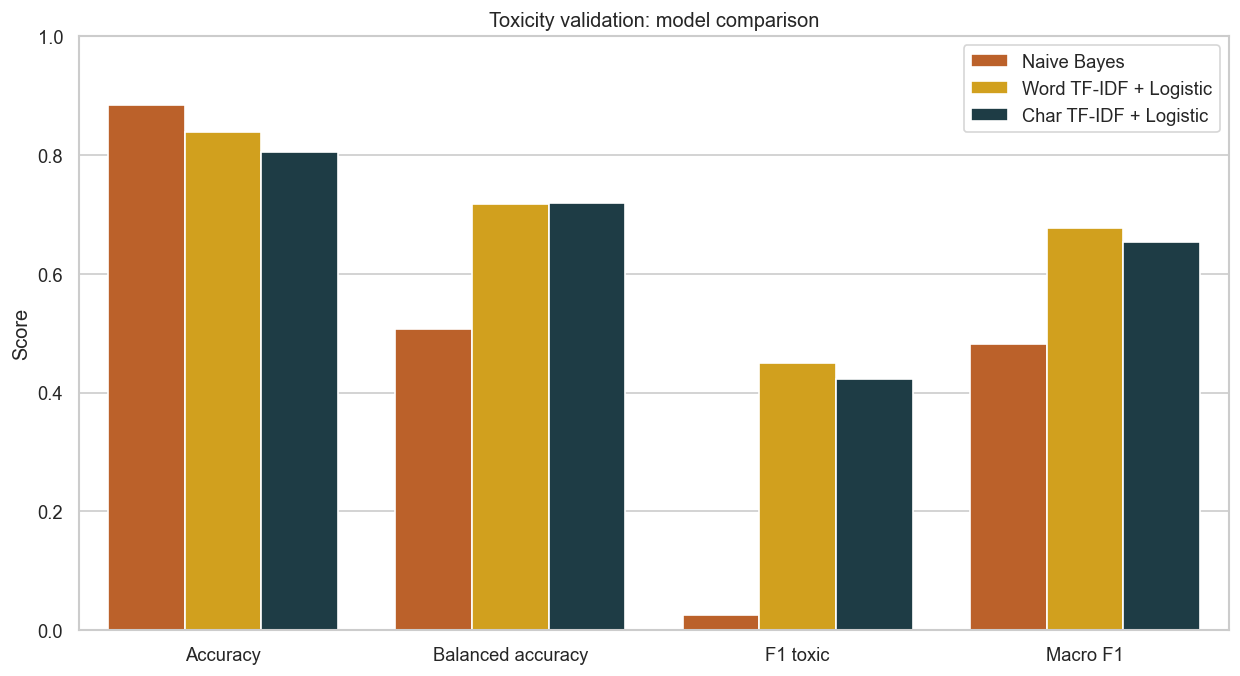

In [35]:
score_plot = toxic_scores.reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score",
)
plt.figure(figsize=(10.5, 5.8))
ax = sns.barplot(data=score_plot, x="Metric", y="Score", hue="index", palette=colors)
ax.set(title="Toxicity validation: model comparison", xlabel="", ylabel="Score", ylim=(0, 1))
ax.legend(title="")
save_plot("text_07_toxic_model_comparison.png")

In [36]:
word_char = toxic_scores.loc[["Word TF-IDF + Logistic", "Char TF-IDF + Logistic"]]
word_char = word_char[["F1 toxic", "Macro F1"]].reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score",
)

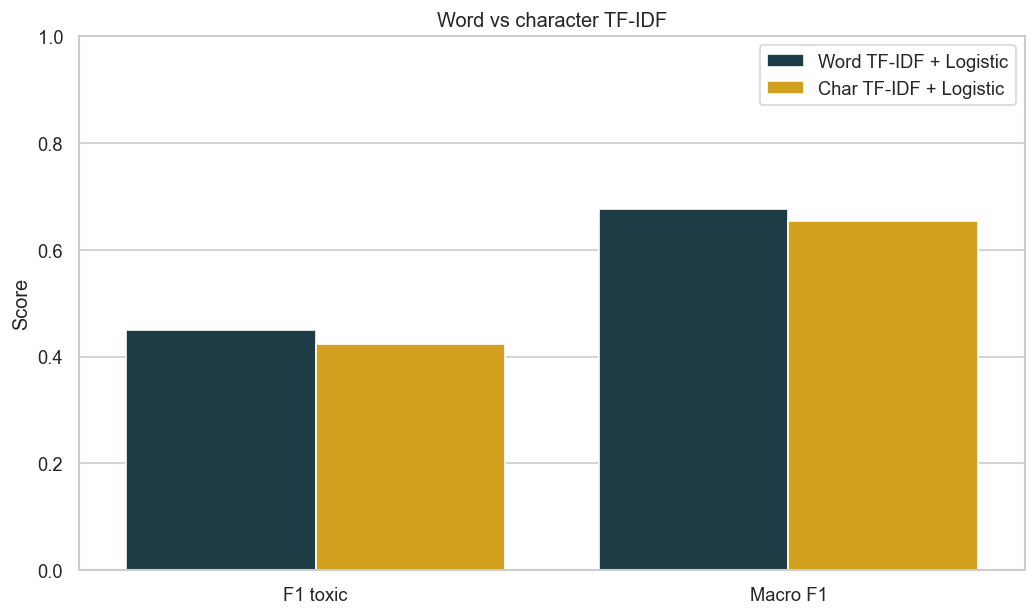

In [37]:
plt.figure(figsize=(8.8, 5.3))
ax = sns.barplot(data=word_char, x="Metric", y="Score", hue="index", palette=["#173f4c", "#efae00"])
ax.set(title="Word vs character TF-IDF", xlabel="", ylabel="Score", ylim=(0, 1))
ax.legend(title="")
save_plot("text_08_word_char_comparison.png")

Word TF-IDF plus Logistic Regression has the best validation macro F1. It is
selected for the final toxicity test.

## 8. Toxicity test results

In [38]:
toxic_test_pred = toxic_word_model.predict(X_test_word)
print("Test accuracy:", round(accuracy_score(test_eval["Toxicity"], toxic_test_pred), 4))
print("Test balanced accuracy:", round(balanced_accuracy_score(test_eval["Toxicity"], toxic_test_pred), 4))
print("Test F1 toxic:", round(f1_score(test_eval["Toxicity"], toxic_test_pred), 4))
print("Test macro F1:", round(f1_score(test_eval["Toxicity"], toxic_test_pred, average="macro"), 4))

Test accuracy: 0.8416
Test balanced accuracy: 0.7324
Test F1 toxic: 0.4507
Test macro F1: 0.6791


In [39]:
print(classification_report(test_eval["Toxicity"], toxic_test_pred, target_names=["Non-toxic", "Toxic"]))

              precision    recall  f1-score   support

   Non-toxic       0.95      0.87      0.91       877
       Toxic       0.36      0.59      0.45       108

    accuracy                           0.84       985
   macro avg       0.65      0.73      0.68       985
weighted avg       0.88      0.84      0.86       985



<Figure size 840x696 with 0 Axes>

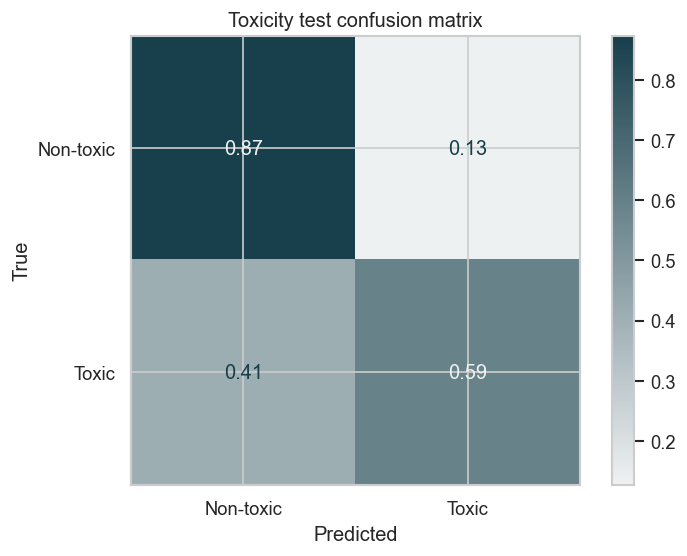

In [40]:
plt.figure(figsize=(7, 5.8))
cm = ConfusionMatrixDisplay.from_predictions(
    test_eval["Toxicity"], toxic_test_pred, normalize="true", values_format=".2f",
    display_labels=["Non-toxic", "Toxic"], cmap=sns.light_palette("#173f4c", as_cmap=True),
)
cm.ax_.set(title="Toxicity test confusion matrix", xlabel="Predicted", ylabel="True")
save_plot("text_09_toxic_confusion_matrix.png")

In [41]:
error_table = test_eval[["Comment", "Topic", "Toxicity"]].copy()
error_table["Prediction"] = toxic_test_pred
error_table = error_table[error_table["Toxicity"] != error_table["Prediction"]]
error_table.head(8)

,Comment,Topic,Toxicity,Prediction
0,Nhiều người cứ nghĩ đạp xe là văn minh. haizzzz,OtoXemay,1,0
8,"Google, intel, Ibm của Mỹ đua công nghệ tạo ra...",KhoaHoc,1,0
10,ko có từ nào hình dung về 2 đứa này đc! ng ta ...,PhapLuat,0,1
11,Cảm giác của nam thanh niên khi bị chúng đe dọ...,PhapLuat,0,1
13,"""Một cô giáo đang dạy âm nhạc ở lớp bên cạnh n...",SucKhoe,0,1
14,thực ra bây giờ mọi người chụp ảnh rất nhiều n...,GiaiTri,0,1
34,Tăng khung phạt lên trộm chó phạt 10 năm tù ! ...,PhapLuat,0,1
45,"chẳng có gì là bất bình đẳng cả, họ là những n...",KinhDoanh,0,1


The error table shows real false positives and false negatives. It is useful
for checking where short or context-dependent comments confuse the model.

## 9. Constructiveness classification

In [42]:
constructive_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
constructive_model.fit(X_train_word, train["Constructiveness"])
constructive_valid_pred = constructive_model.predict(X_valid_word)
constructive_test_pred = constructive_model.predict(X_test_word)

In [43]:
constructive_scores = pd.DataFrame(
    [score_model(valid_eval["Constructiveness"], constructive_valid_pred),
     score_model(test_eval["Constructiveness"], constructive_test_pred)],
    columns=["Accuracy", "Balanced accuracy", "F1 constructive", "Macro F1"],
    index=["Validation", "Test"],
)
constructive_scores.round(4)

,Accuracy,Balanced accuracy,F1 constructive,Macro F1
Validation,0.7835,0.7808,0.7245,0.7731
Test,0.8071,0.8118,0.7607,0.7996


<Figure size 840x696 with 0 Axes>

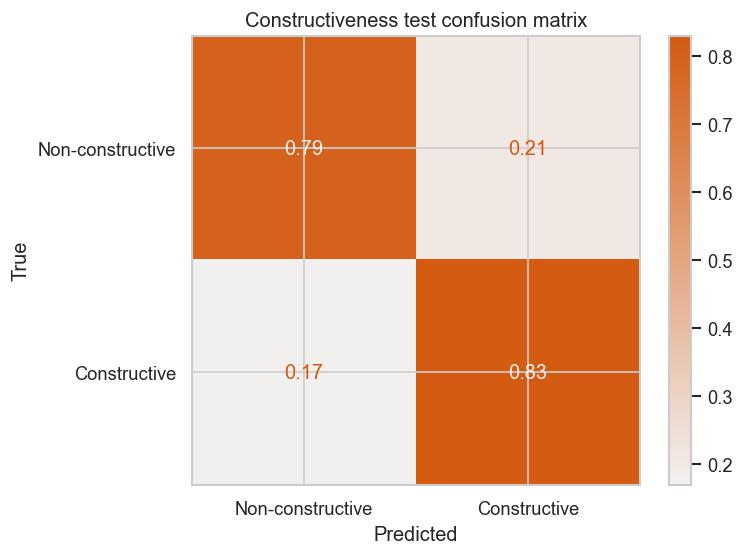

In [44]:
plt.figure(figsize=(7, 5.8))
cm = ConfusionMatrixDisplay.from_predictions(
    test_eval["Constructiveness"], constructive_test_pred, normalize="true", values_format=".2f",
    display_labels=["Non-constructive", "Constructive"], cmap=sns.light_palette("#d35b12", as_cmap=True),
)
cm.ax_.set(title="Constructiveness test confusion matrix", xlabel="Predicted", ylabel="True")
save_plot("text_10_constructive_confusion_matrix.png")

Constructiveness is easier than toxicity in this baseline because it has a
larger positive class and clearer text patterns in the official split.

## 10. Save results for the website

In [45]:
summary = {
    "rows": len(all_data), "topics": all_data["Topic"].nunique(),
    "duplicate_comments": int(all_data["Comment"].duplicated().sum()),
    "validation_overlap_removed": len(valid) - len(valid_eval),
    "test_overlap_removed": len(test) - len(test_eval),
}

In [46]:
summary["toxicity_test"] = score_model(test_eval["Toxicity"], toxic_test_pred)
summary["constructiveness_test"] = score_model(test_eval["Constructiveness"], constructive_test_pred)
summary["toxicity_validation"] = toxic_scores.round(6).to_dict()

In [47]:
summary_file = project_folder / "reports" / "text_victsd_summary.json"
summary_file.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", summary_file)

Saved: E:\Scientific Research\JOURNAL 2026\ECHO-KINN\site-preview\reports\text_victsd_summary.json


## 11. Conclusion

- ViCTSD provides 10,000 Vietnamese comments from 10 topics.
- The toxicity label is imbalanced, so macro F1 and balanced accuracy matter.
- Word TF-IDF + Logistic Regression beats Naive Bayes and char TF-IDF here.
- Removing overlapping evaluation comments avoids direct text leakage.
- The models help moderation analysis but cannot replace human judgement.